# PPO (Stable Baselines)

In [1]:
import gymnasium as gym


import matplotlib.pyplot as plt


from highway.scripts.environment import get_env, ConfigType
from highway.scripts.run import eval_agent, run_one_episode
from highway.scripts.utils.plotting import (
    plot_rewards_lengths,
    plot_train_rewards_lengths,
)
from highway.scripts.utils.statistics import compute_confidence_interval
from highway.scripts.utils.save_gif import save_gif
from copy import deepcopy

from highway.models.mlp_ppo_sb3.ppo_sb3 import PPO_SB3
import pandas as pd
import numpy as np
import os


In [2]:
env = get_env(seed=1, config_type=ConfigType.SHARED_CORE)
env_CNN = get_env(seed=1, config_type=ConfigType.TEST_CNN)

eval_seeds = list(range(50))

In [3]:
best_model_path = os.path.join("logs", "mlp_ppo_sb3", "checkpoints", "ppo_model_125000_steps")

ppo_sb3_agent = PPO_SB3.load(best_model_path, env=env)

ppo_progress = pd.read_csv(os.path.join("logs", "mlp_ppo_sb3", "progress.csv"))
ppo_train_monitor = pd.read_csv(os.path.join("logs", "mlp_ppo_sb3", "train_monitor.csv"), comment="#")

losses = ppo_progress["train/loss"].values
rewards = ppo_train_monitor["r"].values
lengths = ppo_train_monitor["l"].values

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


c:\python_envs\RL_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


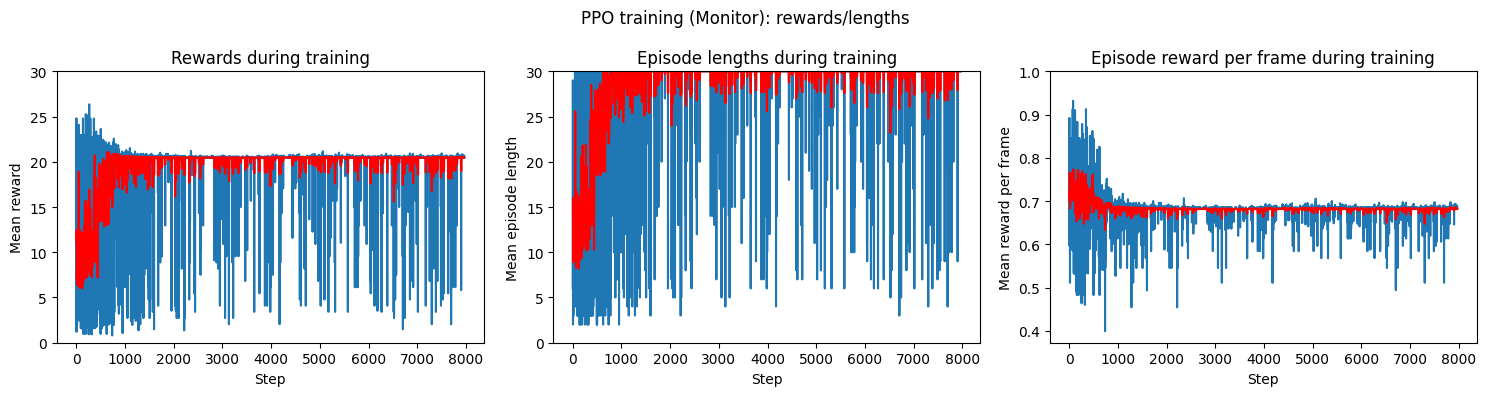

In [4]:
ppo_train_rewards = rewards
ppo_train_lengths = lengths

plot_train_rewards_lengths(
    ppo_train_rewards,
    ppo_train_lengths,
    nb_smoothen=10,
    title="PPO training (Monitor): rewards/lengths",
 )

In [5]:
def plot_ppo_progress_metrics(progress_df, title="PPO training metrics (SB3 progress.csv)"):
    # Prefer timesteps on x-axis when available
    if "time/total_timesteps" in progress_df.columns:
        x = progress_df["time/total_timesteps"].to_numpy()
        x_label = "Timesteps"
    else:
        x = np.arange(len(progress_df))
        x_label = "Steps (rows in progress.csv)"

    metric_specs = [
        ("rollout/ep_rew_mean", "rollout/ep_rew_mean"),
        ("rollout/ep_len_mean", "rollout/ep_len_mean"),
        ("train/approx_kl", "train/approx_kl"),
        ("train/clip_fraction", "train/clip_fraction"),
        ("train/entropy_loss", "train/entropy_loss"),
        ("train/value_loss", "train/value_loss"),
        ("train/explained_variance", "train/explained_variance"),
        ("train/policy_gradient_loss", "train/policy_gradient_loss"),
        ("train/loss", "train/loss"),
        ("train/learning_rate", "train/learning_rate"),
    ]

    present = []
    for col, label in metric_specs:
        if col not in progress_df.columns:
            continue
        series = progress_df[col]
        if hasattr(series, "dropna") and series.dropna().empty:
            continue
        present.append((col, label))

    if not present:
        print("No PPO metrics found in progress.csv (columns differ from expected SB3 PPO logs).")
        return

    ncols = 2
    nrows = int(np.ceil(len(present) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
    axs = np.array(axs).reshape(-1)

    # Rolling window for smoothing (adapt to run length)
    window = max(1, len(progress_df) // 50)

    for ax, (col, label) in zip(axs, present):
        y = progress_df[col].to_numpy()
        ax.plot(x, y, alpha=0.8)
        # Smoothed curve (robust to NaNs)
        try:
            y_smooth = pd.Series(y).rolling(window=window, min_periods=1).mean().to_numpy()
            ax.plot(x, y_smooth, color="red", linewidth=2)
        except Exception:
            pass
        ax.set_title(label)
        ax.set_xlabel(x_label)
        ax.grid(True, alpha=0.2)

    for ax in axs[len(present):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

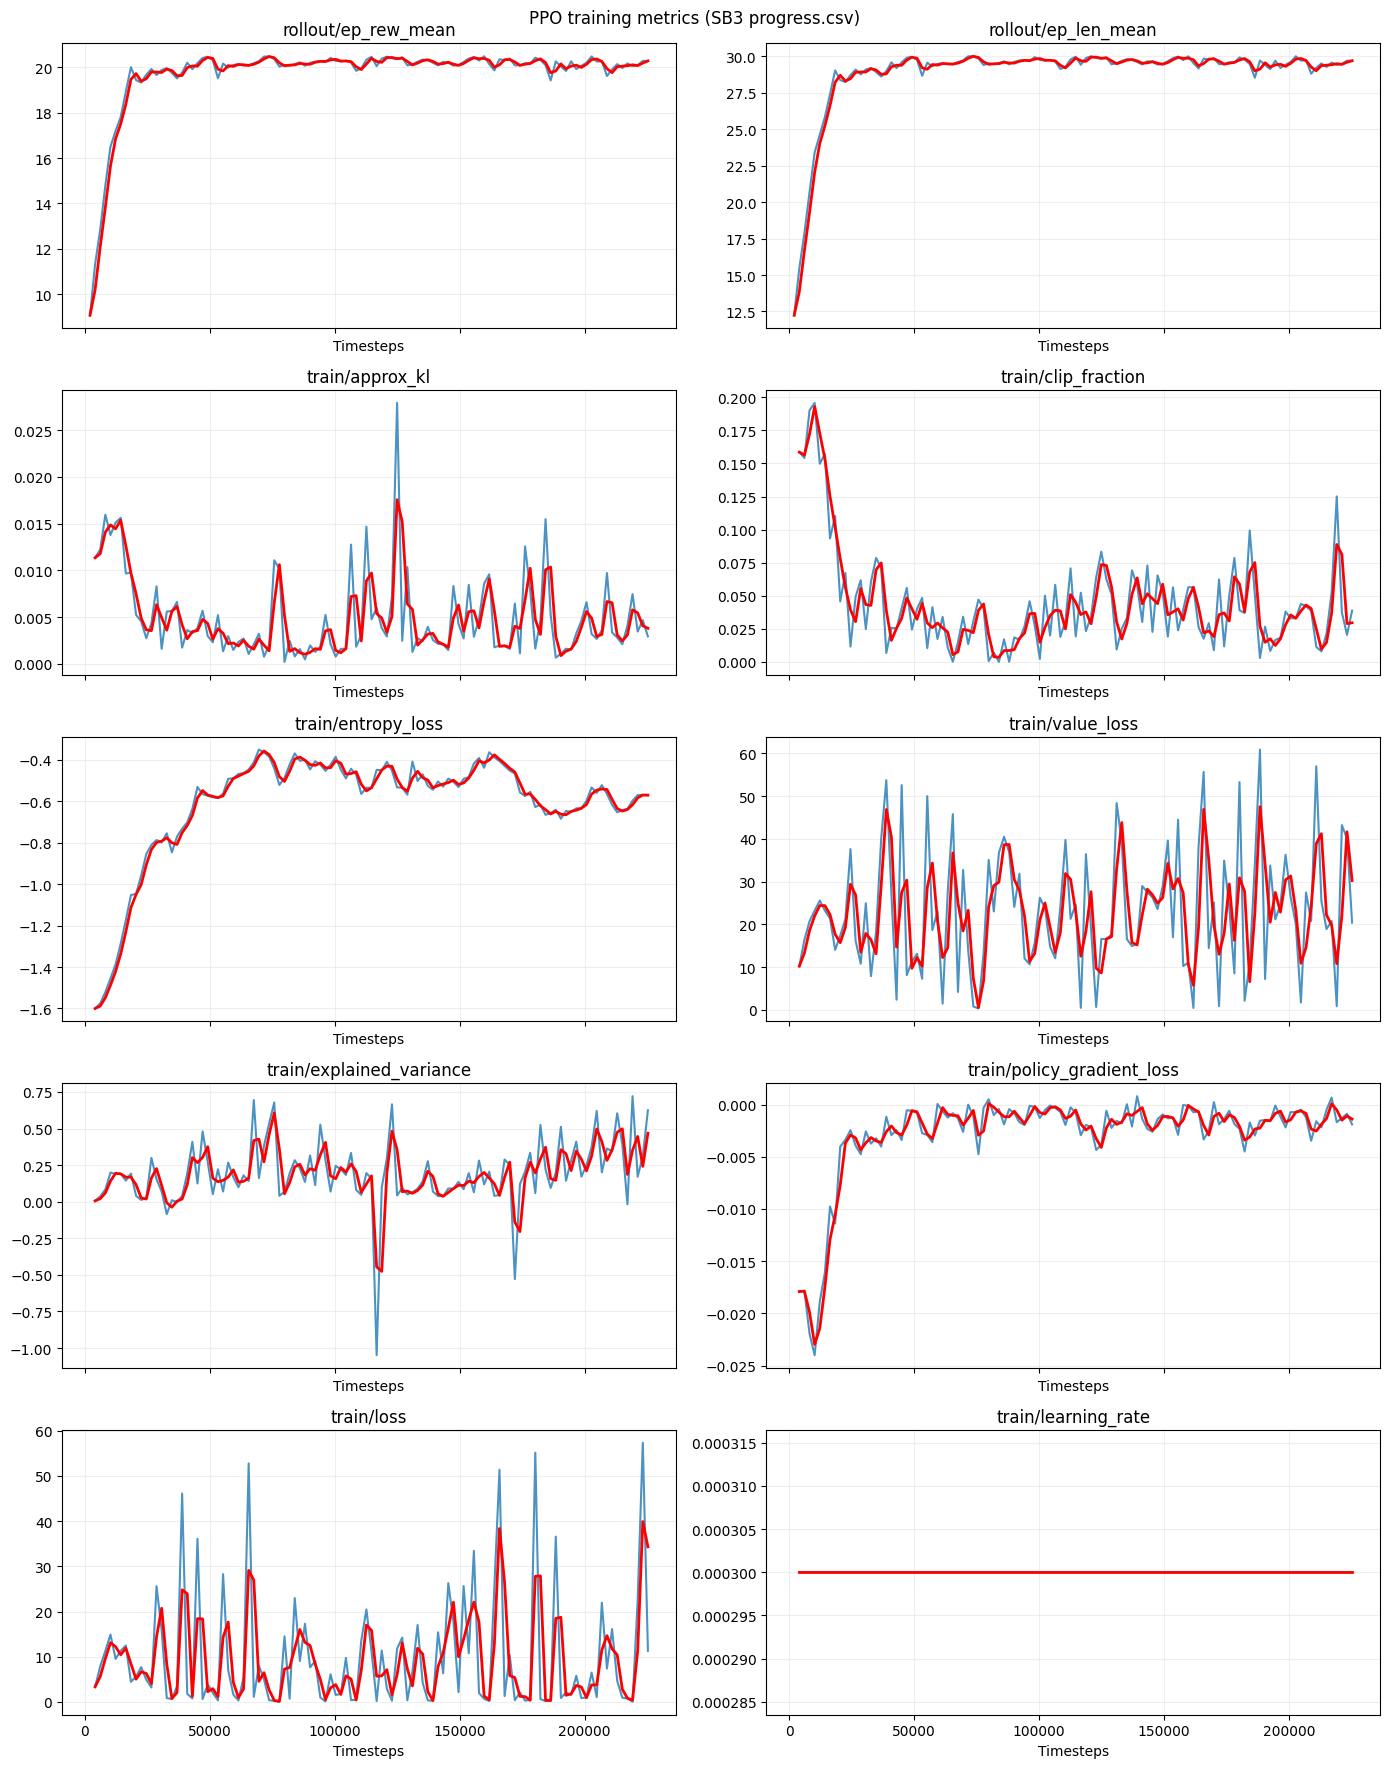

In [6]:
plot_ppo_progress_metrics(ppo_progress)

Evaluating: 100%|██████████| 50/50 [04:13<00:00,  5.07s/ep]

PPO Reward: 20.45 ± 0.00 (95% CI: [20.45, 20.45])
PPO Length: 30.00 ± 0.00 (95% CI: [30.00, 30.00])


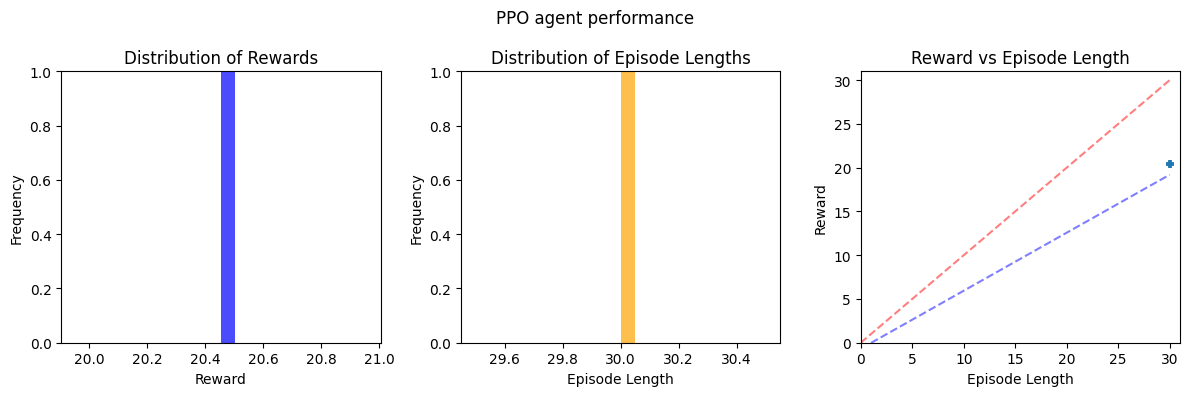

In [7]:
ppo_eval_rewards, ppo_eval_lengths = eval_agent(
    env,
    ppo_sb3_agent,
    seeds=eval_seeds,
    show_progress=True,
 )

stats_rewards = compute_confidence_interval(ppo_eval_rewards)
stats_lengths = compute_confidence_interval(ppo_eval_lengths)

print(f"PPO Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"PPO Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

plot_rewards_lengths(ppo_eval_rewards, ppo_eval_lengths, title="PPO agent performance")

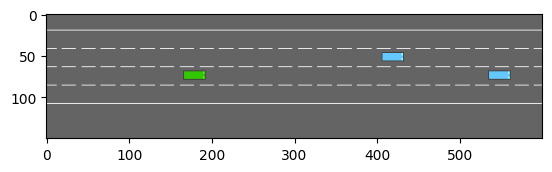

Episode reward=20.45, length=30


In [8]:
should_save = True
seed = 4

reward, length = run_one_episode(env, ppo_sb3_agent, display=True, seed=seed)

if should_save:
    save_gif(env, ppo_sb3_agent, path="manual_ppo_sb3_agent.gif", seed=seed)